In [ ]:
import sys
import os
project_root = os.path.dirname(os.path.abspath('.'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
__package__ = 'rampa'


import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import requests
import json
from shapely.geometry import Polygon, Point, MultiPolygon
from pyproj import Transformer
from rampa.query.arcgis_tools import ArcGISQuery, Data_Collection

/Users/admin/Desktop/personal_projects/Madrid Open Data/madrid-open-data/.venv/lib/python3.12/site-packages/arcgis/auth/_auth/_token.py:479: SyntaxWarning: invalid escape sequence '\s'
  "step-1c": re.compile("var\s+(\w+)\s*=\s*({.*?})", re.DOTALL),
/Users/admin/Desktop/personal_projects/Madrid Open Data/madrid-open-data/.venv/lib/python3.12/site-packages/arcgis/gis/__init__.py:6110: SyntaxWarning: invalid escape sequence '\s'
  >>> job = gis_destination.groups.clone([group], offline=True, save_folder=r"c:\storage", file_name="groups)
/Users/admin/Desktop/personal_projects/Madrid Open Data/madrid-open-data/.venv/lib/python3.12/site-packages/arcgis/gis/__init__.py:9679: SyntaxWarning: invalid escape sequence '\{'
  new_path = f"{current_path}\{title}" if current_path else title
/Users/admin/Desktop/personal_projects/Madrid Open Data/madrid-open-data/.venv/lib/python3.12/site-packages/arcgis/gis/__init__.py:14409: SyntaxWarning: invalid escape sequence '\A'
  >>> item.download("C:\ARCGIS

In [2]:
# Read the URLs from the JSON file

with open('../rampa/data/urls.json', 'r') as f:
    urls = json.load(f)

In [7]:
urls

{'AREAS_ACTIVIDADES_PARA_MAYORES': 'https://sigma.madrid.es/hosted/rest/services/GEOPORTAL/AREAS_ACTIVIDADES_PARA_MAYORES/MapServer/0'}

In [3]:
dd = Data_Collection(urls) # Create an instance of Data_Collection with the URLs
dd.download_data() # Download the data using the Data_Collection instance

  0%|          | 0/1 [00:00<?, ?it/s]

Creating FeatureLayer from URL https://sigma.madrid.es/hosted/rest/services/GEOPORTAL/AREAS_ACTIVIDADES_PARA_MAYORES/MapServer/0


100%|██████████| 1/1 [00:18<00:00, 18.56s/it]


In [4]:
dd.data.keys()

dict_keys(['AREAS_ACTIVIDADES_PARA_MAYORES'])

In [5]:
dd.data['AREAS_ACTIVIDADES_PARA_MAYORES'].crs

<Projected CRS: EPSG:25830>
Name: ETRS89 / UTM zone 30N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Europe between 6°W and 0°W: Faroe Islands offshore; Ireland - offshore; Jan Mayen - offshore; Norway including Svalbard - offshore; Spain - mainland - onshore and offshore.
- bounds: (-6.0, 35.26, 0.01, 80.49)
Coordinate Operation:
- name: UTM zone 30N
- method: Transverse Mercator
Datum: European Terrestrial Reference System 1989 ensemble
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

<Axes: >

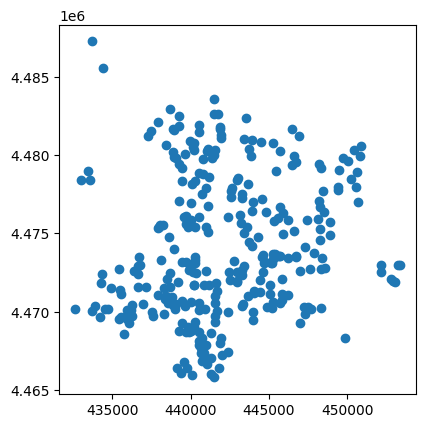

In [6]:
dd.data['AREAS_ACTIVIDADES_PARA_MAYORES'].plot()

In [9]:
dd.data['AREAS_ACTIVIDADES_PARA_MAYORES']


,ESRI_OID,DESC_CLASIFICACION,TIPO,ESTADO,FECHA_INSTALACION,TOTAL_ELEM,TIPO_VIA,NOM_VIA,NUM_VIA,NDP,DIRECCION_AUX,COD_POSTAL,BARRIO,DISTRITO,OBJECTID,SHAPE
0,1,Área de mayores,MAYORES,OPERATIVO,2004-01-01,9,<NA>,<NA>,<NA>,11006381,"Pza · PLAZA COMENDADORAS , ASCENDIENTE 1: 015 · U",<NA>,UNIVERSIDAD,CENTRO,1,POINT (439837.18 4475417.538)
1,2,Área de mayores,MAYORES,OPERATIVO,2004-01-01,16,<NA>,<NA>,<NA>,11005467,"Pza · PLAZA PLAZA DOS DE MAYO , ASCENDIENTE 1: 01",<NA>,UNIVERSIDAD,CENTRO,2,POINT (440301.829 4475401.703)
2,3,Área de mayores,MAYORES,OPERATIVO,2004-01-01,2,GLORIETA,PUERTA DE TOLEDO,1,20105763,"Pza · PLAZA PLAZA PUERTA DE TOLEDO , ASCENDIENTE",28005,EMBAJADORES,CENTRO,3,POINT (439694.34 4473203.414)
3,4,Área de mayores,MAYORES,OPERATIVO,2007-04-24,10,<NA>,<NA>,<NA>,31047998,Parque · PARQUE PARQUE /CASINO DE LA REINA/(C/EMB,<NA>,EMBAJADORES,CENTRO,4,POINT (440249.13 4473137.655)
4,5,Área de mayores,MAYORES,OPERATIVO,2011-04-15,2,<NA>,<NA>,<NA>,11005153,"Pza · PLAZA PLAZA SANTA BARBARA , ASCENDIENTE 1:",<NA>,JUSTICIA,CENTRO,5,POINT (440953.794 4475414.478)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300,301,Área de mayores,MAYORES,OPERATIVO,2022-02-24,11,CALLE,MADRES DE LA PLAZA DE MAYO,5,20169092,C/VICENTE ESPINEL,28017,PUEBLO NUEVO,CIUDAD LINEAL,301,POINT (445598.543 4476007.538)
301,302,Área de mayores,MAYORES,OPERATIVO,2022-02-24,11,CALLE,GABRIEL MONTERO,5,20076103,"C · CALLE GANDHI , ASCENDIENTE 1: 152 · PUEBLO NU",28017,PUEBLO NUEVO,CIUDAD LINEAL,302,POINT (446566.606 4475140.79)
302,303,Área de mayores,MAYORES,OPERATIVO,2022-03-28,7,CALLE,BASILICA,17,11029304,ORENSE,28020,CUATRO CAMINOS,TETUAN,303,POINT (441011.31 4477874.668)
303,304,Área de mayores,MAYORES,OPERATIVO,2022-04-04,8,CALLE,VIZCONDE DE ARLESSON,37,11093791,CV C/DE LA IMAGEN,28018,SAN DIEGO,PUENTE DE VALLECAS,304,POINT (443356.563 4470485.518)
